# Predictive Modeling 
##### notebook code (C) 2022-2026 Timothy James Becker
## CH8: Tree Regression and Classification Overview

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/eb/Decision_Tree.jpg/330px-Decision_Tree.jpg" width=200>

Tree methods can be thought of as a method to partition the variable space.  That is to say they divide the original input space by calculating regression or decision hyper-plane segments such that a portion of the training points are contained in each resulting subspace (for a 2D space they would be line segments). They are called trees because like a binary tree they subdivide the space recursively and have an ordering over the brnaches which are called nodes where a value is used to partition.

In [1]:
import numpy as np
import pandas as pd
import itertools as it
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt
from ISLP import load_data

In [2]:
D    = np.asarray([[10,8,11,15,11,10,12,9],[1,2,3,1,3,3,2,1],[4,6,2,2,4,1,5,3]],dtype=np.float32)
cols = ['X','Y','Z']
D    = pd.DataFrame(D.T,columns=cols)
D

,X,Y,Z
0,10.0,1.0,4.0
1,8.0,2.0,6.0
2,11.0,3.0,2.0
3,15.0,1.0,2.0
4,11.0,3.0,4.0
5,10.0,3.0,1.0
6,12.0,2.0,5.0
7,9.0,1.0,3.0


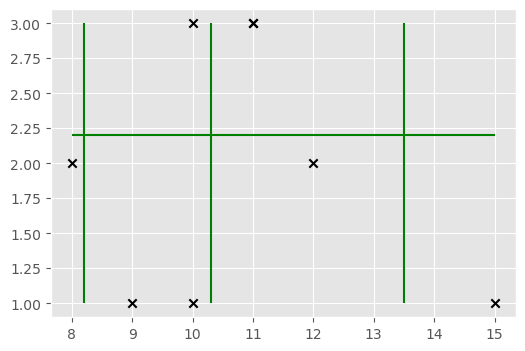

In [3]:
plt.style.use('ggplot')
plt.figure(figsize=(6,4))
plt.scatter(D[:]['X'],D[:]['Y'],color='black',marker='x')
plt.vlines([8.2,10.3,13.5],ymin=np.min(D[:][['Y']]),ymax=np.max(D[:][['Y']]),color='green')
plt.hlines([2.2],xmin=np.min(D[:][['X']]),xmax=np.max(D[:][['X']]),color='green')

### 8.1.1 Regression Trees

We want to pick partitioning hyperplane segments such that the RSS is minimized:

$\displaystyle\sum_{j=1}^{J}\sum_{i \in R_j}{(y_i-\hat{y}R_j)^2}$

So every $j$ possible split at value $s$ would generate two subspaces:

$R_1(j,s) = \{X|X_j<s\}$ and $R_2(j,s) = \{X|X>=s\}$

which gives us:

$\displaystyle\sum_{i:i \in R_1(j,s)}(y_i-\hat{y}R_1)^2 + \sum_{i:i \in R_2(j,s)}(y_i-\hat{y}R_2)^2$

Next we prune the tree which is the process ofremoving branches in order to improve the fit (reduce the natural overfitting that binary splitting produces)

In [4]:
data = load_data('Hitters')
data[1:10]

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A
6,185,37,1,23,8,21,2,214,42,1,30,9,24,N,E,76,127,7,70.0,A
7,298,73,0,24,24,7,3,509,108,0,41,37,12,A,W,121,283,9,100.0,A
8,323,81,6,26,32,8,2,341,86,6,32,34,8,N,W,143,290,19,75.0,N
9,401,92,17,49,66,65,13,5206,1332,253,784,890,866,A,E,0,0,0,1100.0,A


<u> Prediction </u>

Our regression tree then uses the inter-cluster averages to estimate the value of the predictor variable.  As we will see if we make the clusters small we are actually overfitting the data and if we make the clusters too large we are actually using the average!

In [14]:
#clear Nan for salary
idx   = np.where(~np.isnan(data[:]['Salary']))[0]

In [15]:
split  = 0.2
train  = list(np.random.choice(idx,int(len(data)*(1.0-split)),replace=False))
test   = list(set(idx).difference(set(train)))
len(train),len(test)

(257, 6)

In [16]:
data.loc[train]

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
222,381,110,9,61,45,32,7,3015,834,40,451,249,168,N,E,228,7,5,800.000,N
192,491,141,11,77,47,37,15,4291,1240,84,615,430,340,A,E,239,8,2,525.000,A
183,328,91,12,51,43,33,2,342,94,12,51,44,33,N,E,145,59,8,125.000,N
87,280,82,16,44,45,47,2,428,113,25,61,70,63,A,E,148,4,2,110.000,A
84,614,163,29,89,83,75,11,5017,1388,266,813,822,617,N,W,303,6,6,1900.000,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,181,41,1,15,21,33,2,232,50,4,20,29,45,A,E,326,29,5,67.500,A
10,574,159,21,107,75,59,10,4631,1300,90,702,504,488,A,E,238,445,22,517.143,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.000,N
205,209,56,12,22,36,19,2,216,58,12,24,37,19,N,E,201,6,3,90.000,N


In [17]:
data.loc[test]

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
218,374,94,5,36,26,62,7,1968,519,26,181,199,288,N,W,756,64,15,875.0,N
240,271,77,5,35,29,33,12,4933,1358,48,630,435,403,A,W,62,90,3,450.0,A
276,581,145,17,66,68,21,2,831,210,21,106,86,40,N,E,320,465,32,155.0,N
153,341,95,6,48,42,20,10,2964,808,81,379,428,221,N,W,158,4,5,100.0,N
122,539,139,5,93,58,69,5,1469,369,12,247,126,198,A,W,462,9,7,400.0,A
252,486,145,11,51,76,40,11,3967,1102,67,410,497,284,N,E,88,204,16,500.0,A


In [18]:
Dtr = tree.DecisionTreeRegressor().fit(data.loc[train][['Hits','RBI','Walks','Years']],data.loc[train]['Salary'])
Dtr

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [19]:
pred = Dtr.predict(data.loc[test][['Hits','RBI','Walks','Years']])

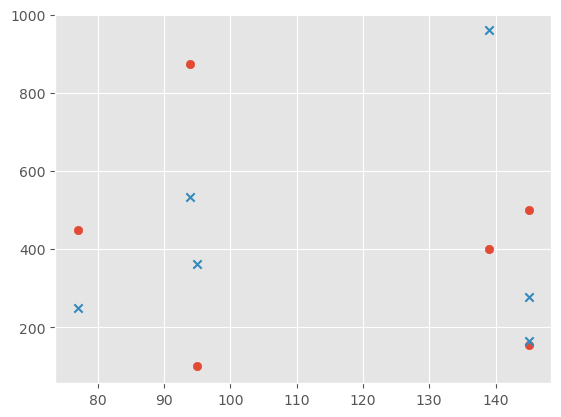

In [20]:
plt.scatter(data.loc[test]['Hits'],data.loc[test]['Salary'])
plt.scatter(data.loc[test]['Hits'],pred,marker='x')

In [13]:
#plot the other X values agaist the True/Predicted

In [ ]:
# what is the total error of the tree model to our data using the test partitions?

In [113]:
# pick another ISLP dataset to work with and do a regression tree to compare with a linear regression...

[ISLP datasets](https://islp.readthedocs.io/en/latest/data.html)

#### 8.1.2 Classification Trees

Instead of using the predicted value on the quatititative variable we can also use the tree to predict the qualititative variable which we will now call a classification tree. Here we use the entropy of the observed distribution of the cluster labeling which corrects for variance and other shortcoming of the direct proportion:

$D = \displaystyle\sum_{k=1}^{K}\hat{p}_{mk}\text{log}(\hat{p}_{mk})$

<u> Question </u>  
Why can the tree handle quatitative, qualitative, ordinal, non-ordinal data without transformations like the general linear models we discussed?

In [22]:
Dtc = tree.DecisionTreeClassifier().fit(data.loc[train][['Salary','Hits','RBI']],data.loc[train]['League'])
Dtc

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
true = np.asarray(data.loc[test]['League'])
pred = Dtc.predict(data.loc[test][['Salary','Hits','RBI']])
pred

array(['N', 'N', 'N', 'N', 'A', 'A'], dtype=object)

In [24]:
acc = 0
for i in range(len(pred)):
    if pred[i]==true[i]: acc += 1
acc/len(pred)

0.6666666666666666

In [25]:
# try another variable from Hitters or load in a new data set with qualitative data and try building a Tree!

### 8.2 Tree Ensembles (Bagging and Random Forest)

So we learned that Tree methods can be used to approximate the non-linear space by partitioning which creates sub-spaces.  These rectangles (from recursive binary splitting) are then used by way of averaging or by calculating the observed class proportions.  The main issue is the balance of the fit since the tree tends to over fit and must be pruned back to become more generally applicable. What if instead of pruning them back we instead build many trees each of which will specialize in one area? Then we would need a way to combine their community decisions and estimates.

#### <u>Bootstrap Aggregation (Bagging)</u>

Similiar to how we partition our full dataset into a training and test datset using our test split proportion (10 or 20 percent) we use a similiar approach to improve upon the standard partition and prune tree models (8.1.1, 8.1.2). Here we will use our combinatorics to choose some portion of the training data points.  Lets first see how this will work and then do some analysis on the result using our <b>Wage</b> data set from ISRL2.

Lets assume we have $n$ original rows and we have used a test split $s \in [0.1-0.3]$, then we would have $r=n(1-s)$ rows remaining to choose from. How many ways can we sample from $r$?

$\begin{pmatrix}r \\ r\end{pmatrix}+\begin{pmatrix}r \\ r-1\end{pmatrix} + ... + \begin{pmatrix}r \\ 2\end{pmatrix}+\begin{pmatrix}r \\ 1\end{pmatrix}$

Since each (n choose k term) has a combinatorial solution: 
$\begin{pmatrix}n \\ k\end{pmatrix} = \frac{n!}{(n-k)!k!}$

We will get:
$\displaystyle \sum_{i=0}^{r-1}\begin{pmatrix}r \\ r-i\end{pmatrix} = \sum_{i=0}^{1}(\frac{r!}{(r-(r-i))!(r-i)!}) = $
$\frac{r!}{(r-r)!r!}+\frac{r!}{(r-(r-1))!(r-1)!}+...+\frac{r!}{(r-2)!2!}+\frac{r!}{(r-1)!1!} = (1)+(r)+...+r(r-1)/2+(r)$

In [26]:
data = load_data('Wage')
data

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154
...,...,...,...,...,...,...,...,...,...,...,...
2995,2008,44,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,5.041393,154.685293
2996,2007,30,2. Married,1. White,2. HS Grad,2. Middle Atlantic,1. Industrial,2. >=Very Good,2. No,4.602060,99.689464
2997,2005,27,2. Married,2. Black,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.193125,66.229408
2998,2005,27,1. Never Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,4.477121,87.981033


In [27]:
n = 3000 #number of rows in wage dataset
s = 0.2
r = round(n*(1-s))
r        #how many ways could we have sampled this r rows for training?

2400

In [28]:
idx = np.where(data[:]['wage']>125)[0]
len(idx)

868

In [29]:
high     = np.zeros((n,),dtype=np.int8)
high[idx] = 1
data.loc[:,'high'] = high 

In [30]:
#super mass conversion (don't care what happens...)
for col in data.columns:
    try:
        data[col] = data[col].cat.codes
    except Exception as e: pass

In [31]:
data

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage,high
0,2006,18,0,0,0,0,0,0,1,4.318063,75.043154,0
1,2004,24,0,0,3,0,1,1,1,4.255273,70.476020,0
2,2003,45,1,0,2,0,0,0,0,4.875061,130.982177,1
3,2003,43,1,2,3,0,1,1,0,5.041393,154.685293,1
4,2005,50,3,0,1,0,1,0,0,4.318063,75.043154,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2008,44,1,0,2,0,0,1,0,5.041393,154.685293,1
2996,2007,30,1,0,1,0,0,1,1,4.602060,99.689464,0
2997,2005,27,1,1,0,0,0,0,1,4.193125,66.229408,0
2998,2005,27,0,0,2,0,0,1,0,4.477121,87.981033,0


#### <u>Some Helper Functions Please....</u>

In [32]:
def accuracy(T,P,c=0):
    a = 0
    for i in range(len(T)):
        if T[i]==c and T[i]==P[i]: a += 1
    n = a/np.sum([(1 if e==c else 0)for e in T])
    m = a/np.sum([(1 if e==c else 0)for e in P])
    return 2*(n*m)/(n+m)

In [33]:
accuracy([1,0,1],[1,0,0],c=0)

np.float64(0.6666666666666666)

In [34]:
#some code ideas for how to generate combinations of data row indecies
for i,j in it.combinations(range(3),2):
    print(i,j)

0 1
0 2
1 2


#### <u>Simulate By Running Many Times</u>

In [219]:
cols   = ['year','age','education']
split  = 0.2
train  = list(np.random.choice(range(len(data)),int(len(data)*(1.0-split)),replace=False))
test   = list(set(range(len(data))).difference(set(train)))

#sample some of the training now, take a group of half
s = 0.2
M = []
for i in range(1):
    idx = list(np.random.choice(train,int(len(train)*s),replace=False))
    Dtc = tree.DecisionTreeClassifier().fit(data.loc[idx][cols],data.loc[idx]['high'])
    M += [Dtc]
len(M)

1

In [220]:
P = np.zeros((len(M),len(test)),dtype=np.int8)
for i in range(len(M)):
    pred = M[i].predict(data.loc[test][cols])
    for j in range(len(pred)):
        P[i][j] = pred[j]
ens_pred = np.asarray(np.round(np.mean(P,axis=0),0),dtype=np.int8)
ens_pred[0:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0], dtype=int8)

In [221]:
true = np.asarray(data.loc[test]['high'],dtype=np.int8)
true[0:10]

array([0, 0, 0, 1, 0, 0, 0, 1, 0, 1], dtype=int8)

In [222]:
c0 = accuracy(true,ens_pred,c=0)
c1 = accuracy(true,ens_pred,c=1)
2*(c0*c1)/(c0+c1)

0.552066450567261

#### Bagging Theory

If you played around with the above proceedure than you will eventually understand that building partial models from sampled rows will have significant variance which affect the model performance. By build model paramters using multiple samply rounds via averageing naturally will diminish variance over the large possible space (see the total ways you can sample the Wage datset above...).

$\displaystyle \hat{f}_{bag}(x) = \frac{1}{B} \sum_{b=1}^{B} \hat{f}^{*b}(x)$

#### <u>Random Forest</u>

We have seen how we can use multiple trees by averaging (ensemble) and we will now look at others ways of combining trees that we decorrelate the tree used for combination.  If we can combine trees that are decorrelated this will reduce the variance and lead to better results in terms of final fit (and accuracy).  Here we can not only sample from the potential rows of data, but similar to what we did with our multiple linear regression we can sample our predictors as well!  If we pick a small number of predictor to consider using the same combinatorial strategy we will guarantee that we will be combining many different view points from our weak classifiers.

In [21]:
Rfc = RandomForestClassifier(n_estimators=1).fit(data.loc[train][cols],data.loc[train]['high'])
Rfc

KeyError: "None of [Index(['X', 'Y', 'Z'], dtype='object')] are in the [columns]"

In [231]:
pred = Rfc.predict(data.loc[test][cols])
c0 = accuracy(true,pred,c=0)
c1 = accuracy(true,pred,c=1)
2*(c0*c1)/(c0+c1)

0.5858547988708538